# Initialize

In [2]:
import os
import re
import time
import pickle
import random
import math
import sys
from pathlib import Path
from typing import List, Dict, Tuple
from collections import defaultdict, Counter
from datetime import datetime
import pandas as pd
import numpy as np
from tqdm import tqdm

from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
from scipy.spatial.distance import pdist

from xgboost import XGBRegressor
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import BertConfig, BertModel, get_linear_schedule_with_warmup

import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

import warnings
warnings.filterwarnings("ignore")

os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
os.environ['OMP_NUM_THREADS'] = '1'



/Users/nottreepat/Downloads/KilterTransformer-2/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
import os, sys
from pathlib import Path
project_root = Path(__file__).resolve().parent.parent if '__file__' in globals() else Path.cwd().parent

os.chdir(project_root)
sys.path.insert(0, str(project_root))
os.getcwd()

'/Users/nottreepat/Downloads/KilterTransformer-2'

In [3]:
## moved from utils to src folder

from src.data_processing import DataPreprocessing, HOLDCOORDINATES, HOLD_ID
from src.visualization import Visualization
from src.evaluation import Evaluation
# from src.encoding_experiment import ExperimentRunner, MatrixEncoder, StatsEncoder, MatrixStatsEncoder, GraphEncoder, SequenceEncoder
from src.tokenizer import build_vocab, train_tokenizer, tokenize_datasets
from src.bert_ass import KilterBERT, BoulderDataset, KilterEncoder, train_and_evaluate
from src.gpt import KilterGPT
# from src.generate import 


# Read sqlite3 - done once

In [6]:
# import os

# # Directory to save CSVs
# output_dir = "/Users/nottreepat/Downloads/boardlibagain/csv_exports"
# os.makedirs(output_dir, exist_ok=True)

# for table_name_tuple in tables:
#     table_name = table_name_tuple[0]  # tuple to string
#     try:
#         # Read table into DataFrame
#         df = pd.read_sql_query(f"SELECT * FROM {table_name}", conn)
        
#         # Save to CSV
#         csv_path = os.path.join(output_dir, f"{table_name}.csv")
#         df.to_csv(csv_path, index=False)
#         print(f"Saved {table_name} to {csv_path}")
#     except Exception as e:
#         print(f"Could not save table {table_name}: {e}")

# # Close connection
# conn.close()


# Data Processing

In [4]:
from src.data_processing import DataPreprocessing
dp = DataPreprocessing()
datasets = dp.load_climbs(cache_path="data/climbs_cleaned.csv")

print(f"\nTotal samples: {len(datasets)}")

sample = datasets[0]
print(f"\nSample columns: {list(sample.keys())}")
print(f"\nSample data:")
for k in ['name', 'v_grade', 'angle_y', 'num_holds', 'frames', 'holds_data']:
    if k in sample:
        print(f"  {k}: {sample[k]}")

Loaded 76992 routes from cache data/climbs_cleaned.csv

Total samples: 76992

Sample columns: ['name', 'frames', 'holds_data', 'display_difficulty', 'angle_y', 'quality_average', 'ascensionist_count', 'v_grade', 'letter_grade', 'num_holds', 'num_hand', 'num_footonly', 'hand_foot_ratio', 'avg_reach', 'max_reach', 'route_area', 'hold_density', 'popularity_score', 'angle_x_holds', 'density_x_angle']

Sample data:
  name: zoumba
  v_grade: 5
  angle_y: 30
  num_holds: 7
  frames: angle30_grade22_start1136_feet1169_hand1234_hand1253_hand1353_finish1391_feet1453
  holds_data: [{1136: 'start'}, {1169: 'feet'}, {1234: 'hand'}, {1253: 'hand'}, {1353: 'hand'}, {1391: 'finish'}, {1453: 'feet'}]


In [6]:
# 80-10-10 split
train_test = datasets.train_test_split(test_size=0.2, seed=42)
val_test = train_test['test'].train_test_split(test_size=0.5, seed=42)

datasets = {
    'train': train_test['train'],
    'val': val_test['train'],
    'test': val_test['test']
}

print(f"Train size: {len(datasets['train'])}")
print(f"Val size: {len(datasets['val'])}")
print(f"Test size: {len(datasets['test'])}")

Train size: 61593
Val size: 7699
Test size: 7700


# Visualization

In [1]:
import os, sys
from pathlib import Path
project_root = Path(__file__).resolve().parent.parent if '__file__' in globals() else Path.cwd().parent

os.chdir(project_root)
sys.path.insert(0, str(project_root))
os.getcwd()

'/Users/nottreepat/Downloads/KilterTransformer-2'

In [10]:
from src.visualization import Visualization
from src.data_processing import DataPreprocessing
dp = DataPreprocessing()
df = dp.load_climbs().to_pandas()
viz = Visualization()
df[(df['name'] == 'Bell of the Wall') & (df['angle_y'] == 40)]['frames'] #8260

# viz.plot_hold_ids([1379,1348, 1339, 1268], all_holds=False, save_fig=False)
# viz.plot_boulder(df.iloc[8260]['frames'], name=df.iloc[8260]['name'], save_fig=True, show_ids=True)
# viz.plot_hold_ids(all_holds=True, save_fig=True)
df.iloc[8260]['frames']

Loaded 76992 routes from cache data/climbs_cleaned.csv


'angle40_grade18_feet1169_feet1183_feet1198_start1234_start1236_hand1268_hand1284_hand1317_hand1353_finish1387'

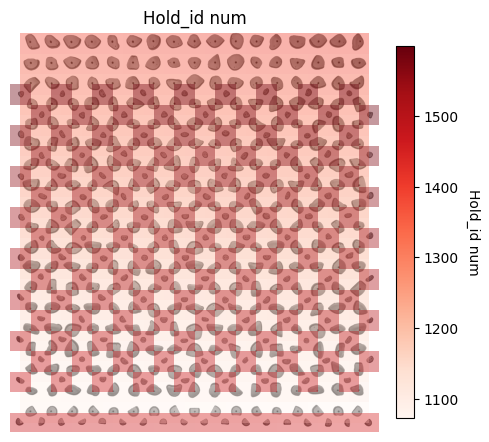

In [9]:
from collections import defaultdict
from src.data_processing import HOLD_ID
hold_id_dict = {hold_id: int(hold_id) for hold_id in HOLD_ID}


viz.plot_heatmap(hold_id_dict, title="Hold_id num", hold_type='all')


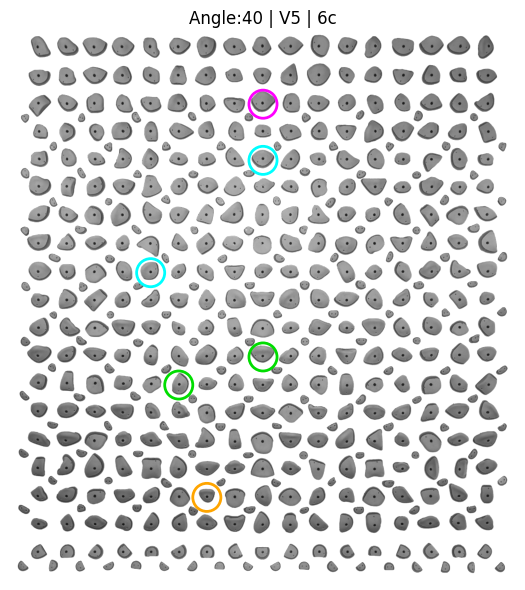

In [3]:
from src.visualization import Visualization
viz = Visualization()
# viz.plot_hold_ids(all_holds=True, save_fig=False)
# viz.plot_hold_ids([1379,1348, 1339, 1268], all_holds=False, save_fig=False)

data =  "angle45_grade23_feet1078_start1153_hand1184_hand1254_hand1283_hand1285_hand1314_hand1366_finish1379_feet1498_feet1522_feet1529"
data = "angle40_grade20_start1180_start1200_feet1113_finish1353_hand1247_hand1319"
# data = [{1078: 'feet'}, {1153: 'start'}, {1184: 'hand'}, {1254: 'hand'}, {1283: 'hand'}, {1285: 'hand'}, {1314: 'hand'}, {1366: 'hand'}, {1379: 'finish'}, {1498: 'feet'}, {1522: 'feet'}, {1529: 'feet'}]
viz.plot_boulder(data)

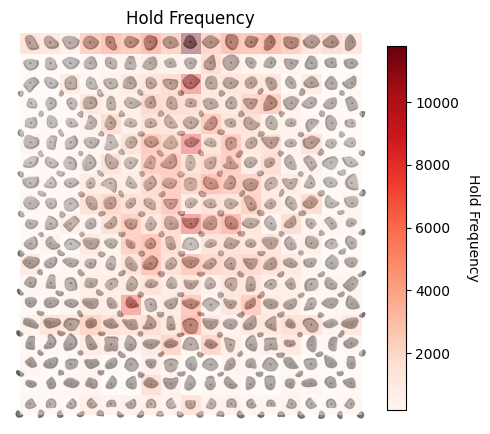

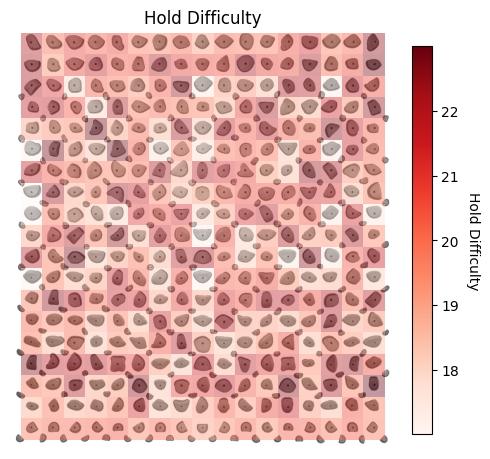

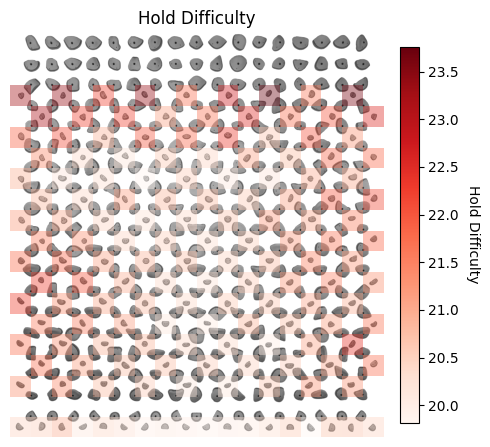

In [4]:

from src.visualization import Visualization
from collections import defaultdict
import pandas as pd
import ast


routes = pd.read_csv("data/climbs_cleaned.csv")
routes['holds_data'] = routes['holds_data'].apply(ast.literal_eval)

# Hold frequency heatmap
hold_freq = defaultdict(int)
for holds in routes['holds_data']:
    for hold in holds:
        hold_freq[list(hold.keys())[0]] += 1

# Hold Difficulty heatmap
hold_difficulties = defaultdict(list)

for _, row in routes.iterrows():
    difficulty = row["display_difficulty"]
    for hold in row["holds_data"]:
        hold_id = list(hold.keys())[0] 
        hold_difficulties[hold_id].append(difficulty)

# average difficulty
hold_avg_diff = {
    hold_id: (sum(vals) / len(vals) if len(vals) > 0 else 0)
    for hold_id, vals in hold_difficulties.items()
}

# Plots
viz = Visualization()
viz.plot_heatmap(dict(hold_freq), title="Hold Frequency", hold_type='main')
viz.plot_heatmap(dict(hold_avg_diff), title="Hold Difficulty", hold_type='main')
viz.plot_heatmap(dict(hold_avg_diff), title="Hold Difficulty", hold_type='auxiliary')


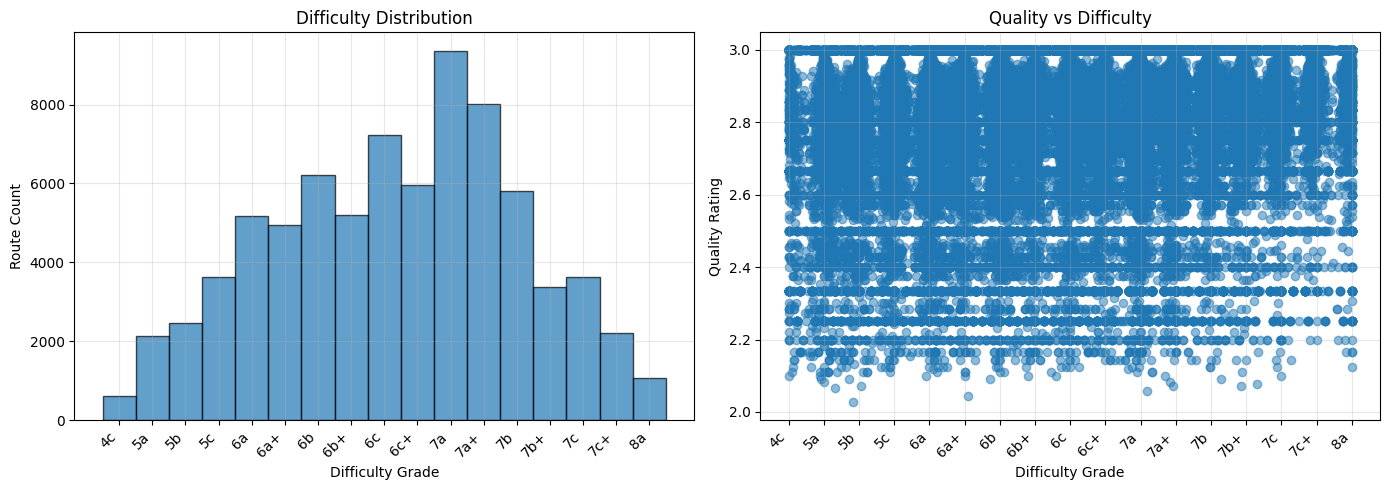

In [5]:
from src.visualization import Visualization
from src.data_processing import DataPreprocessing
import ast
dp = DataPreprocessing()
viz = Visualization()
routes = pd.read_csv("data/climbs_cleaned.csv")
routes['holds_data'] = routes['holds_data'].apply(ast.literal_eval)
viz.plot_difficulty_quality_analysis(routes, dp)

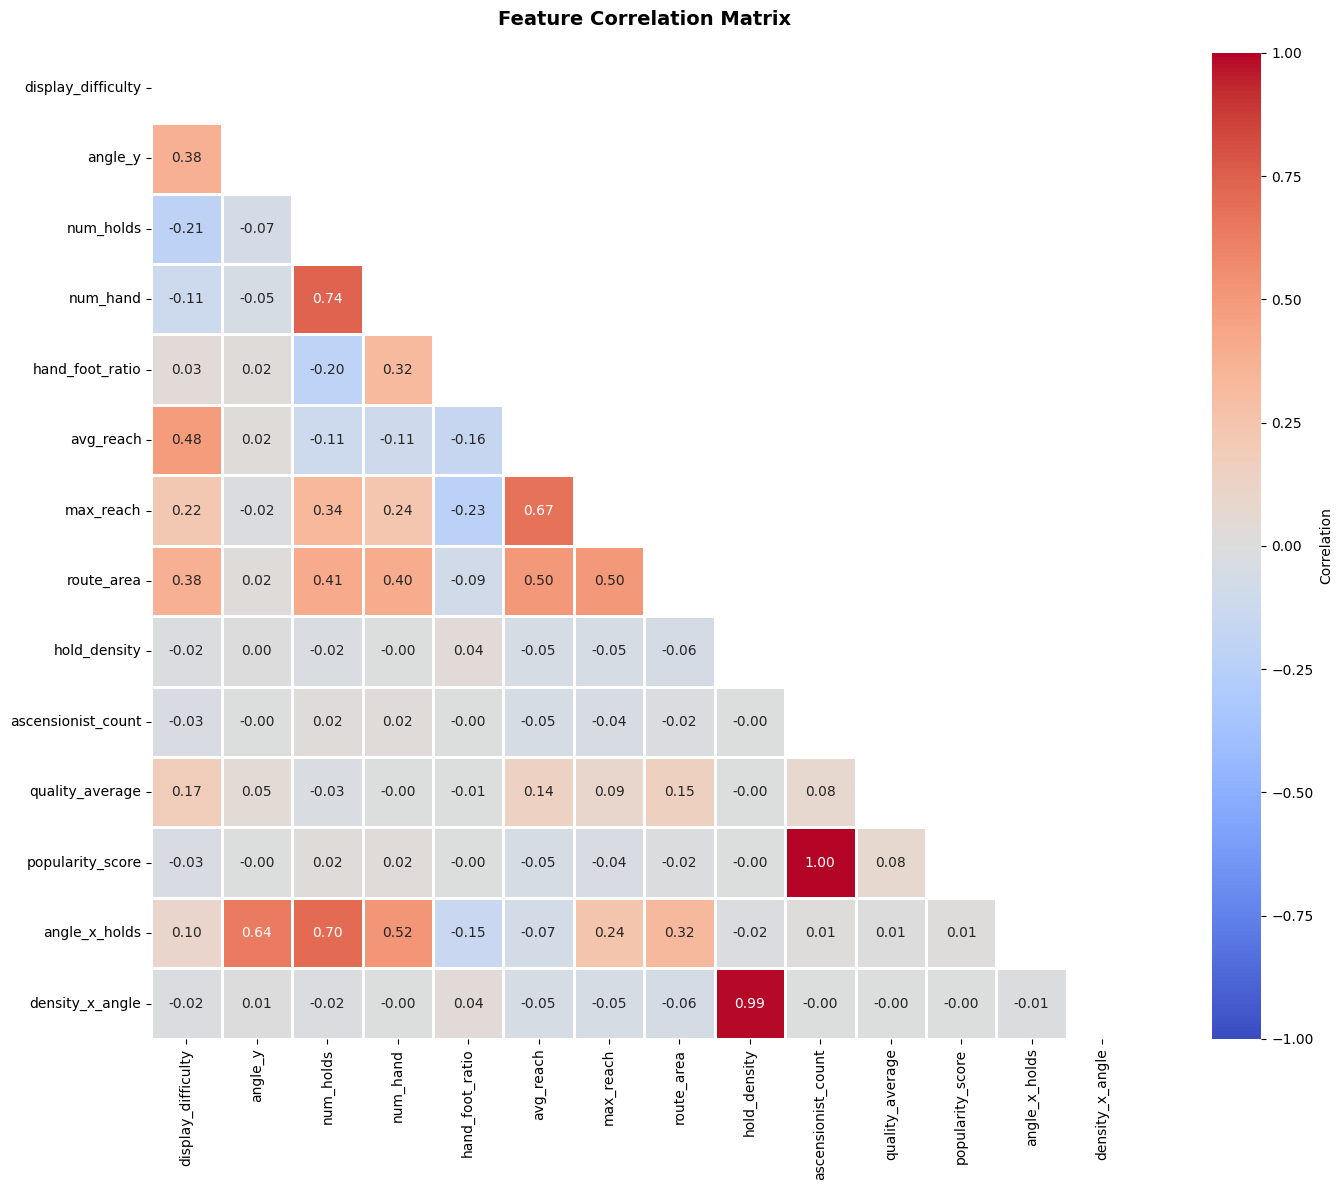

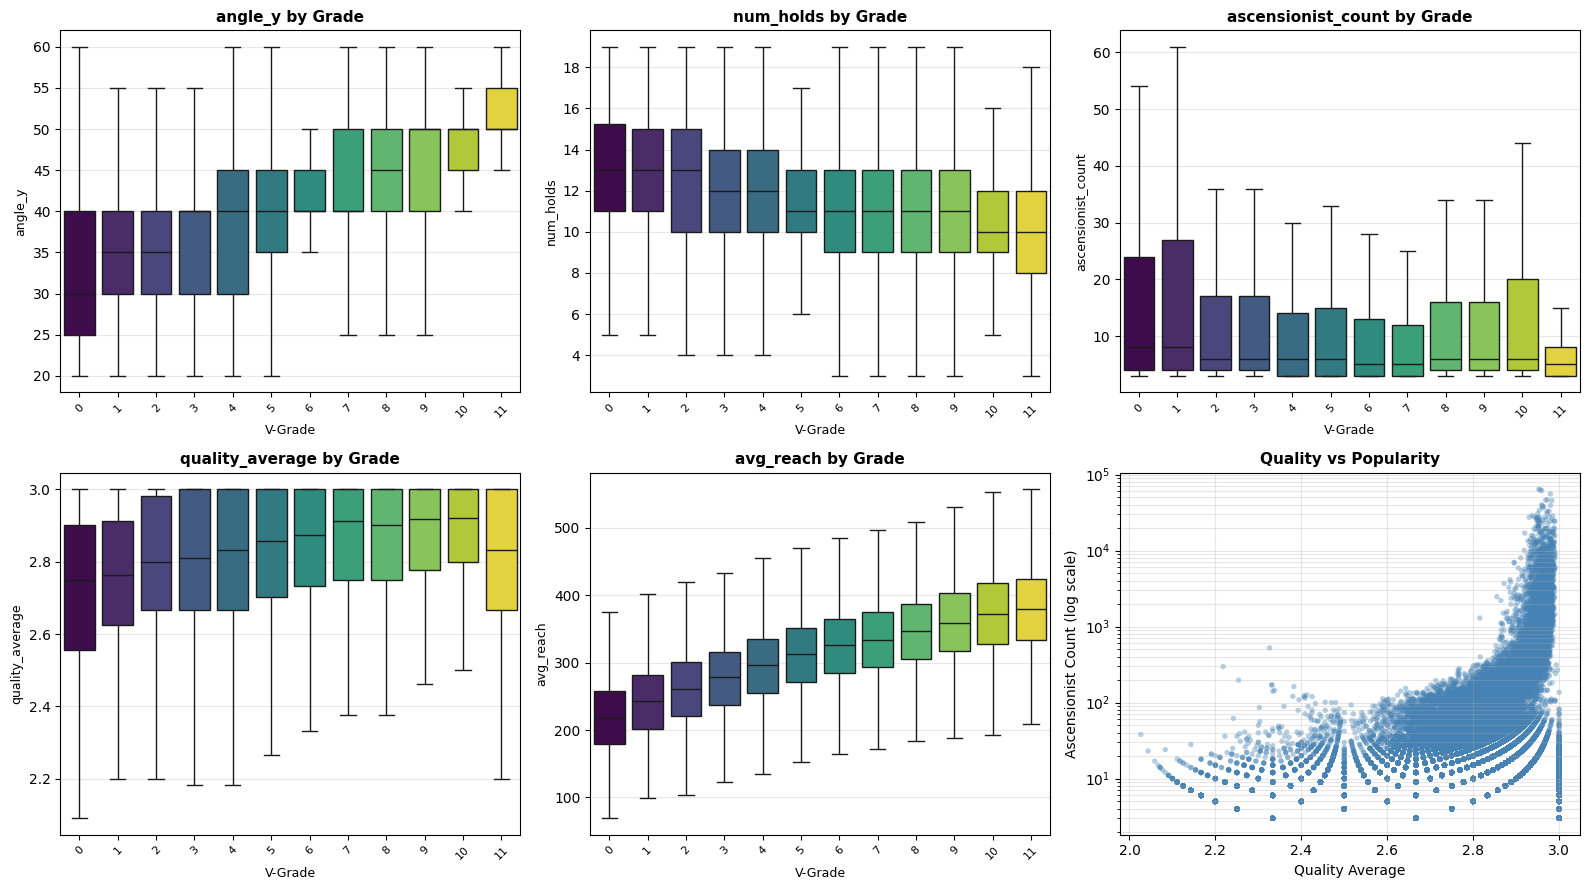

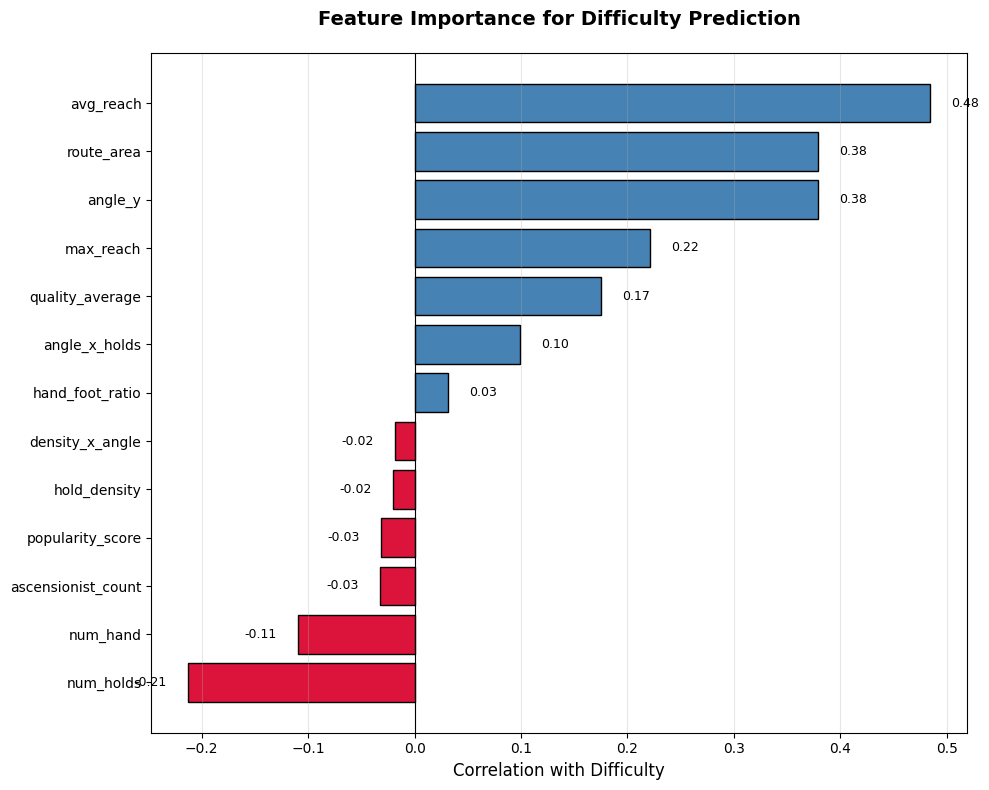

In [6]:
viz = Visualization()
viz.plot_correlation(routes)
viz.plot_distribution(routes)
viz.plot_corr_with_difficulty(routes)


# Dummy XGBoost

In [1]:
# Initialize
from src.data_processing import DataPreprocessing, HOLDCOORDINATES, HOLD_ID
from src.visualization import Visualization
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
import pandas as pd
import ast

dp = DataPreprocessing()
routes = dp.load_climbs()

def extract_features(row):
    coords = []
    funcs = []
    
    MAX_HOLDS = 20
    for hold in row['holds_data'][:MAX_HOLDS]:
        hold_id, func = list(hold.items())[0]
        if hold_id in HOLD_ID:
            idx = HOLD_ID.index(hold_id)
            x, y = HOLDCOORDINATES[idx]
            coords.extend([x, y])
        else:
            coords.extend([0, 0])
        func_map = {'start': 12, 'hand': 13, 'feet': 15, 'finish' : 14}
        funcs.append(func_map.get(func, 0))
    
    # Pad to MAX_HOLDS
    coords.extend([0, 0] * (MAX_HOLDS - len(funcs)))
    funcs.extend([0] * (MAX_HOLDS - len(funcs)))
    
    angle = row.get('angle_y', 0)
    return coords + funcs + [len(row['holds_data']), angle if not pd.isna(angle) else 0]

# # Prepare data
df = routes.to_pandas() # for classical ML
df['holds_data'] = df['holds_data'].apply(ast.literal_eval)

X = df.apply(extract_features, axis=1, result_type='expand').fillna(0)
y = df['display_difficulty']


# Split and train
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=df['v_grade']
)

model = XGBRegressor(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

/Users/nottreepat/Downloads/KilterTransformer/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded 76992 routes from cache data/climbs_cleaned.csv



Gradient Boosting Performance:
  R²:   0.7202
  MAE:  1.5397
  RMSE: 1.9650
  Within ±1 V-grade: 75.28%


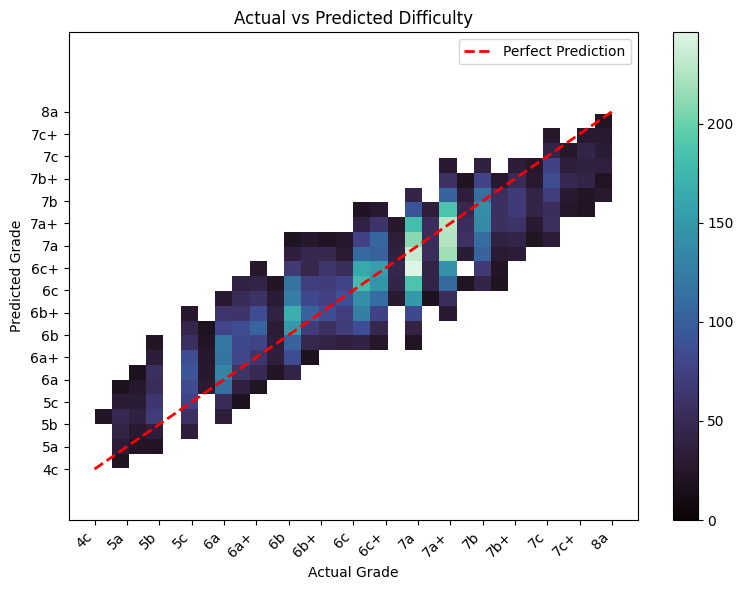

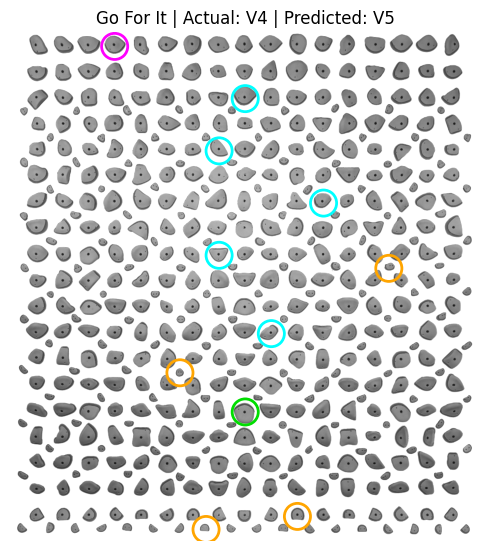

In [13]:
from src.evaluation import Evaluation
import numpy as np

eval = Evaluation()
viz = Visualization()
scores = eval.get_scores(y_test, y_pred, "Gradient Boosting")

# Plot
eval.plot_predictions(y_test, y_pred)


idx = np.random.randint(0, len(y_test))
test_df = df.loc[X_test.index].reset_index(drop=True)
route = test_df.iloc[idx]
actual_diff = y_test.iloc[idx]
pred_diff = y_pred[idx]
actual_v = dp.difficulty_to_v_grade(int(round(actual_diff)))
pred_v = dp.difficulty_to_v_grade(int(round(pred_diff)))
    

viz.plot_boulder(route['holds_data'], name = route['name'], v_grade = actual_v, predicted_v_grade = pred_v)


In [12]:
# import numpy as np

# # Make sure test_df matches X_test
# test_df = df.loc[X_test.index].reset_index(drop=True)

# # Convert y_test and y_pred to aligned DataFrame for convenience
# results = test_df.copy()
# results["actual_diff"] = y_test.values
# results["pred_diff"] = y_pred

# # Convert numeric difficulty → V-grade
# results["actual_v"] = results["actual_diff"].round().astype(int).apply(dp.difficulty_to_v_grade)
# results["pred_v"] = results["pred_diff"].round().astype(int).apply(dp.difficulty_to_v_grade)

# # Loop through each unique actual V-grade
# for v in sorted(results["actual_v"].unique()):
#     subset = results[results["actual_v"] == v]
#     if subset.empty:
#         continue

#     # Pick one random route from that grade
#     route = subset.sample(1).iloc[0]

#     viz.plot_boulder(route["holds_data"], name=route["name"], v_grade=route["actual_v"], predicted_v_grade=route["pred_v"],)


# Clustering

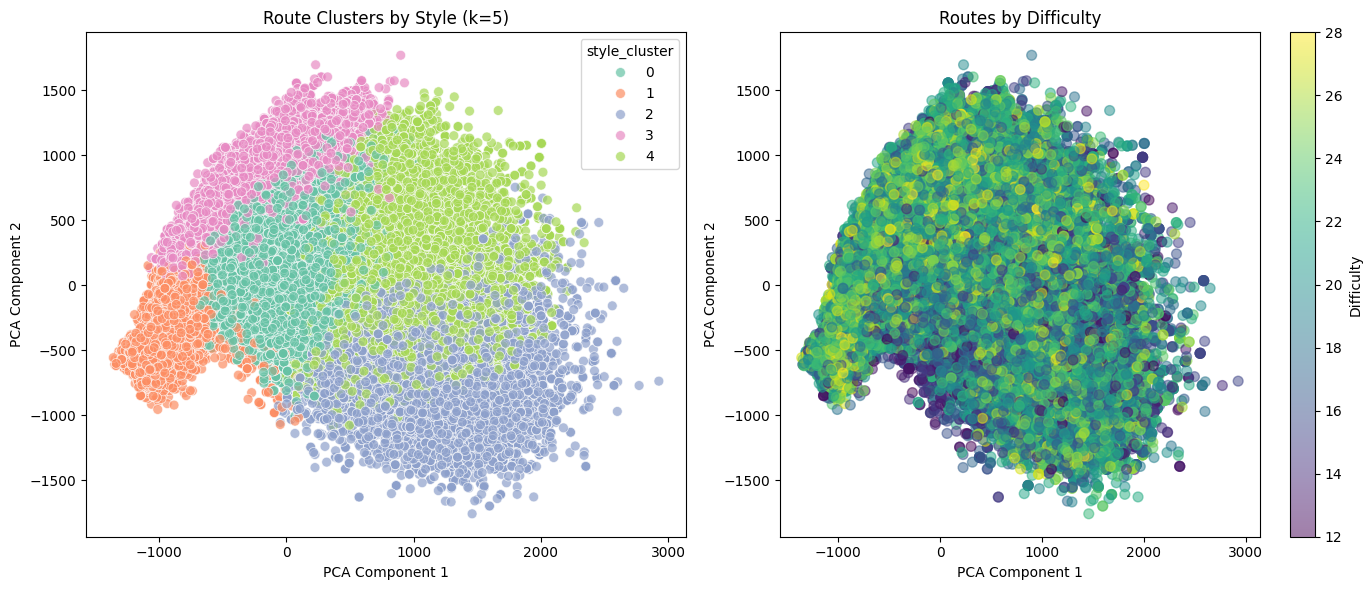


Cluster 0: thanks for the filing cabinet | V4 | 20°


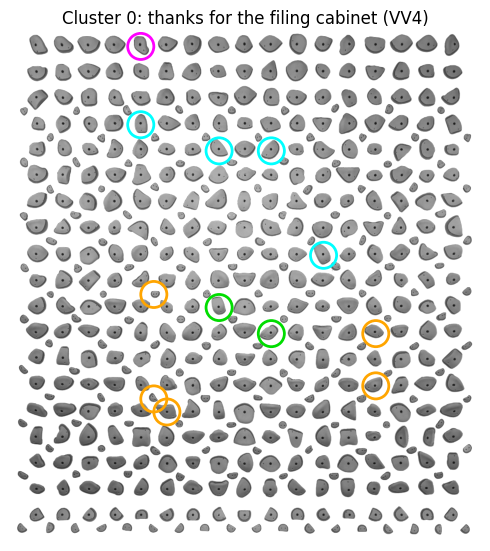


Cluster 1: Camelback’s Revenge | V5 | 30°


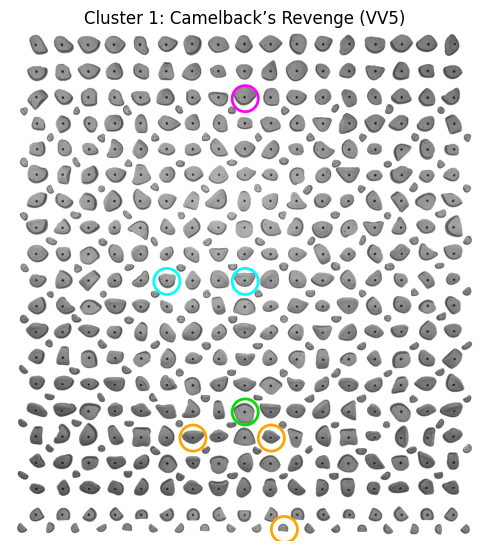

In [ ]:
from sklearn.cluster import KMeans
from src.visualization import Visualization


viz = Visualization()
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df["style_cluster"] = kmeans.fit_predict(X)

# viz.plot_clustering(X, df, cluster_col='style_cluster')

# Show only 2 representatives with boulders
viz.plot_clustering(X, df, cluster_col='style_cluster', 
                   n_representatives=2, plot_boulders=True)


# Encoding Experiment

In [ ]:
from src.evaluation import Evaluation
from src.encoding_experiment import *
from src.data_processing import DataPreprocessing
from src.visualization import Visualization
import ast
import pandas as pd

dp = DataPreprocessing()
routes = dp.load_climbs().to_pandas()
routes['holds_data'] = routes['holds_data'].apply(ast.literal_eval)
print(f"Dataset: {len(routes)} routes")

runner = ExperimentRunner()
results = []

results.append(runner.run(
    MatrixEncoder(),
    XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    routes,
    "Matrix + XGBoost"
))

results.append(runner.run(
    StatsEncoder(),
    XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    routes,
    "Stats + XGBoost"
))

matrix_enc = MatrixEncoder()
results.append(runner.run(
    matrix_enc,
    Trainer(SimpleCNN(), matrix_enc, is_cnn=True, epochs=30, batch_size=128),
    routes,
    "Matrix + CNN",
))

stats_enc = StatsEncoder()
results.append(runner.run(
    stats_enc,
    Trainer(SimpleDense(18), stats_enc, epochs=30, batch_size=256),
    routes,
    "Stats + Dense NN",
))

print("\n" + "="*60)
print("RESULTS SUMMARY")
print("="*60)
comparison = pd.DataFrame([{
    'Method': r['name'],
    'R²': r['scores']['r2'],
    'MAE': r['scores']['mae'],
    'RMSE': r['scores']['rmse'],
    'Time (s)': r['train_time']
} for r in results])
print(comparison.to_string(index=False))

best = comparison.loc[comparison['R²'].idxmax()]
print(f"\nBest: {best['Method']} (R²={best['R²']:.4f}, MAE={best['MAE']:.4f})")

Loaded 76992 routes from cache data/climbs_cleaned.csv
Dataset: 76992 routes

Experiment: Matrix + XGBoost
Encoding features...
Feature shape: (76992, 9217)
Training model...


# GOOD ASS Transformer